In [1]:
sentence = 'The quick brown fox jumps over a lazy dog'
dc = {s: i for i, s in enumerate(sorted(sentence.replace(',', '').split()))}

## Tokenization
Tokenization refers to the method of breaking a given piece of text into multiple tokens.This splitting can be done in multiple ways:
1. Word wise: Does not handle the the out of vocab word very well.
2. Character wise: Make sequence long
...
3. BPE : Byte Pair Encoding.Join multiple chars in sequence of word that occur most frequently.Can handle out of vocab word very well.

In [ ]:
#get all the indices and convert it into tensor ()
from torch import tensor
inp_ten=tensor(data=[dc[i] for i in sentence.split()])
inp_ten

tensor([0, 8, 2, 4, 5, 7, 1, 6, 3])

## Converting the tokens to their embedding vector
The embedding for each layer is learned during training and during inference for each token,we find the embedding vector of token using a lookup table.

Intuitively these embedding vectors consist of a general meaning of tokens.For example let suppose you are doing a word baset tokenization and the word is `House`.So this model will consist of vector the represent the general meaning of house in semantic space.

In [7]:
#conver the input tensor to embedding (each word is converted to its embedding)
import torch.nn as nn
import torch

vocab_size = 50000
torch.manual_seed(123)
embed = nn.Embedding(vocab_size, 16)  # here 16 is the lenght of embedding vector
embedded_sentence = embed(inp_ten).detach() 
embedded_sentence.shape

torch.Size([9, 16])

## Self Attention Mechanism:


### Qualitative Explanation:
The role of self attention mechanims is to change the embedding vector of each token in such a way that they represent the semantic meanning of the token according to the context of the other words in sequence.Mathematically,let suppose the word is `Toy House`.So the attention mechanims will move  the vector representing `House` towards the vector that represent a `House` that looks like `toy`.Like this:

E = Actual E + delta E

where delta E is the change required in Actual E to move towards the `Toy House`.

The final vector in attention mechanism is called attention vector.

### How does it actually implemented in Transformers

In transformers in case of attention module,there are three learnable parameters:
Key,Query,Value

#### Query
The query is a feature vector that describes what we are looking for in the sequence, i.e. what would we maybe want to pay attention to.
It is compared to every other vector to establish the weights for its own output y_i

#### Keys:
The key feature vector roughly describes what the element is “offering”, or when it might be important. The keys should be designed such that we can identify the elements we want to pay attention to based on the query.
It is compared to every other vector to establish the weights for the output of the j-th vector y_j

### Values
The value vector is the one we want to average over.
It is used as part of the weighted sum to compute each output vector once the weights have been established.



Attenion Weights is calculated by using dot product the key and query vectors.The key and query vectors are caculated by multipying the Query Parameters and Key parameters to embedding matrix:
So let suppose embedding matrix is I * D(where D is the dimension of embedding vector).Then the Key and Value parameter dimensions will be KQ * D.

So key and query matrix will be : 
    K=Wk * XT #XT is transform of input embedding matrix
    Q=Wk * XT 

The dimension of K and Q will be KQ * I.Hence basically for each token in embedding matrix we have it key weigths and query weights.In the similar fashion we have value weights for each token in embedding matrix.


In [9]:
torch.manual_seed(123)

d=embedded_sentence.shape[1]
d

16

In [12]:
d_q, d_k, d_v=24,24,28 #dimension of d_q and d_k should be same but can have any value

W_query=torch.nn.Parameter(torch.rand(d_q, d))
W_key=torch.nn.Parameter(torch.rand(d_k, d))
W_value=torch.nn.Parameter(torch.rand(d_v, d)) # value matrix can have any dimension
W_value


Parameter containing:
tensor([[3.6154e-02, 6.0171e-01, 7.9425e-02, 9.2289e-01, 9.3921e-01, 2.7711e-01,
         2.4355e-01, 3.2901e-01, 1.6637e-01, 7.4162e-01, 3.4678e-01, 3.0911e-01,
         1.4319e-01, 7.3659e-01, 1.5216e-01, 2.7247e-01],
        [7.3454e-01, 2.4636e-01, 2.8786e-01, 7.6933e-01, 7.5175e-03, 2.1363e-02,
         9.8768e-02, 4.3495e-01, 7.0685e-01, 8.5439e-01, 8.3460e-01, 9.0942e-01,
         2.4178e-01, 5.4318e-01, 9.9408e-01, 1.8536e-01],
        [5.5266e-02, 3.7982e-01, 9.9005e-01, 9.4376e-02, 2.1871e-01, 4.6632e-01,
         4.8741e-01, 5.5169e-01, 1.6179e-01, 7.2413e-02, 5.7373e-01, 7.0768e-01,
         3.7267e-01, 6.8820e-01, 1.6709e-01, 7.2117e-01],
        [4.0512e-01, 9.2083e-01, 7.9758e-01, 9.9252e-01, 8.4360e-02, 9.0136e-01,
         9.6483e-01, 1.3100e-01, 2.7011e-01, 5.8278e-01, 6.4667e-01, 9.3481e-01,
         9.1841e-01, 6.5929e-01, 7.7894e-01, 7.8968e-01],
        [8.9857e-01, 6.2959e-01, 2.4494e-01, 2.8323e-01, 3.1759e-03, 8.0281e-01,
         7.1997e-

In [13]:
# let calculate attension vector of second element in input

In [14]:
x_2=embedded_sentence[1]
query_2=W_query.matmul(x_2) # dimension of query_2 will be d_q
key_2=W_key.matmul(x_2) # dimension of key_2 will be d_k
value_2=W_value.matmul(x_2) # dimension of value_2 will be d_v
value_2

tensor([-3.4209, -2.5748, -1.4981, -4.4863, -2.1737, -4.4908, -1.9585, -5.2581,
        -2.8334, -4.3643, -3.9407, -4.2450, -2.4600, -2.8633, -3.3276, -2.4233,
        -2.8273, -5.4377, -4.2107, -4.2298, -4.4103, -3.4455, -2.6971, -5.9431,
        -3.5305, -3.0332, -3.4741, -4.7913], grad_fn=<MvBackward0>)

In [15]:
value_2.shape

torch.Size([28])

In [16]:
#cacluating keys and values for all tokens as they will be needed firther in the calculation
keys=W_key.matmul(embedded_sentence.T).T
values=W_value.matmul(embedded_sentence.T).T
print(keys.shape) 
print(values.shape)

torch.Size([9, 24])
torch.Size([9, 28])


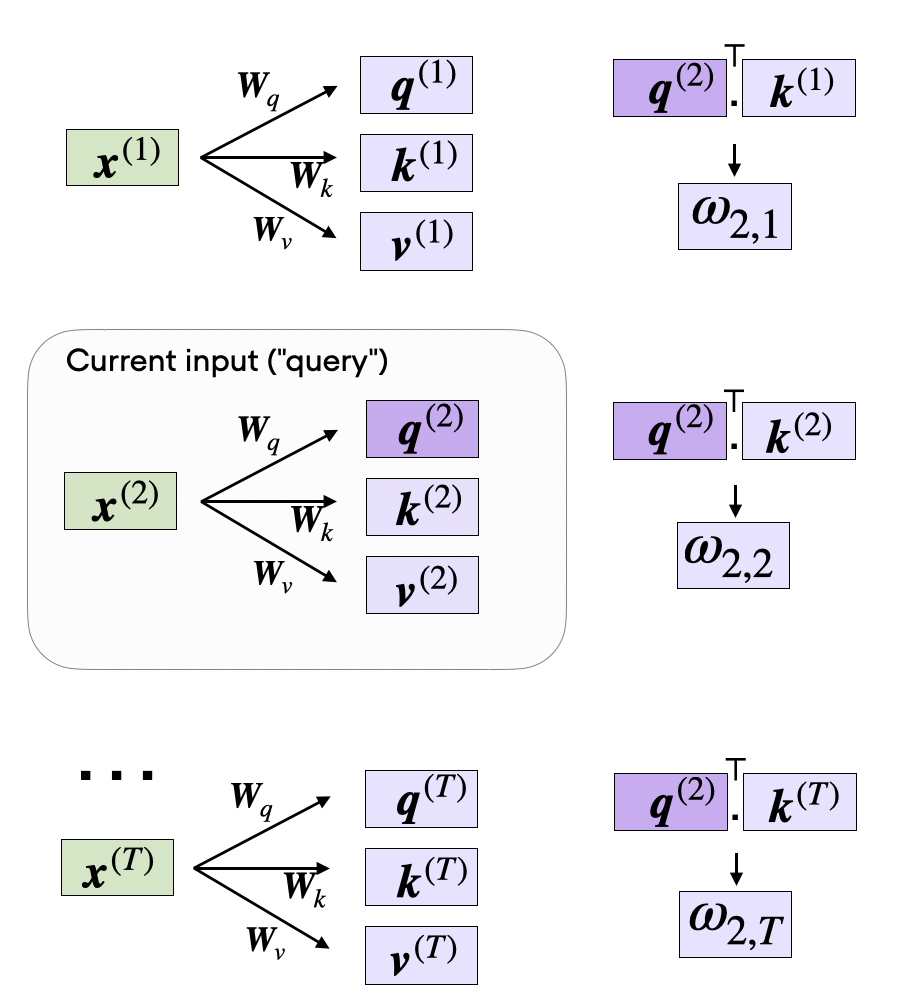

In [23]:
# Here we compute the w values for all input tokens as illustrated in the previous figure
w_2=query_2.matmul(keys.T)

print(w_2.shape)
w_2

torch.Size([9])


tensor([ -69.5598,  248.5541,  120.1886,    5.4767,  208.0338,   77.8689,
          89.9739,  185.0108, -143.5056], grad_fn=<SqueezeBackward4>)

### Attention Scores:
<iframe src="https://www.kaggle.com/embed/aisuko/coding-the-self-attention-mechanism?cellIds=20&kernelSessionId=160449336" height="300" style="margin: 0 auto; width: 100%; max-width: 950px;" frameborder="0" scrolling="auto" title="Coding the Self-Attention Mechanism"></iframe>

In [19]:
import torch.nn.functional as F

attention_weights_2=F.softmax(w_2/d_k**0.5, dim=0)
attention_weights_2

tensor([6.2965e-29, 9.9974e-01, 4.1715e-12, 2.8254e-22, 2.5572e-04, 7.3900e-16,
        8.7450e-15, 2.3269e-06, 1.7531e-35], grad_fn=<SoftmaxBackward0>)

<iframe src="https://www.kaggle.com/embed/aisuko/coding-the-self-attention-mechanism?cellIds=22&kernelSessionId=160449336" height="300" style="margin: 0 auto; width: 100%; max-width: 950px;" frameborder="0" scrolling="auto" title="Coding the Self-Attention Mechanism"></iframe>

In [21]:
context_vector_2=attention_weights_2.matmul(values)
context_vector_2

tensor([-3.4205, -2.5747, -1.4982, -4.4856, -2.1737, -4.4901, -1.9585, -5.2569,
        -2.8326, -4.3640, -3.9405, -4.2448, -2.4600, -2.8633, -3.3274, -2.4235,
        -2.8276, -5.4365, -4.2101, -4.2296, -4.4098, -3.4451, -2.6972, -5.9422,
        -3.5306, -3.0330, -3.4741, -4.7906], grad_fn=<SqueezeBackward4>)

In [22]:
context_vector_2.shape

torch.Size([28])

In [ ]:
https://notesonai.com/attention+mechanism#:~:text=The%20value%20vector%20is%20the,the%20weights%20have%20been%20established.
https://community.deeplearning.ai/t/confusion-about-q-k-and-v-matrices/426146/2
https://sebastianraschka.com/blog/2023/self-attention-from-scratch.html
https://www.kaggle.com/code/aisuko/coding-the-self-attention-mechanism